In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import LinearSegmentedColormap

INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv"
INPUT_PATH = "../../shampu/output/8fts_3miners_ind_ilp_sm1_3456_shapley.csv"
#INPUT_PATH = f"../../shampu/output/shapley_{algorithm}.csv"
INPUT_PATH = "8fts_3miners_ind_ilp_sm1_529416_shapley.csv"


METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]

In [87]:
"""
algorithms = ['sm1', 'inductive', 'ilp']
all_dfs = []

for algo in algorithms:
    input_path = f"../../shampu/output/shapley_{algo}.csv"
    df = pd.read_csv(input_path)
    df['algorithm'] = algo  # Optional: Add a column to track origin
    all_dfs.append(df)

# Combine into one DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df.to_csv(f"../../shampu/output/8fts_3miners_ind_ilp_sm1_529416_shapley.csv",index=False)
"""

'\nalgorithms = [\'sm1\', \'inductive\', \'ilp\']\nall_dfs = []\n\nfor algo in algorithms:\n    input_path = f"../../shampu/output/shapley_{algo}.csv"\n    df = pd.read_csv(input_path)\n    df[\'algorithm\'] = algo  # Optional: Add a column to track origin\n    all_dfs.append(df)\n\n# Combine into one DataFrame\ncombined_df = pd.concat(all_dfs, ignore_index=True)\ncombined_df.to_csv(f"../../shampu/output/8fts_3miners_ind_ilp_sm1_529416_shapley.csv",index=False)\n'

In [124]:
data = pd.read_csv(INPUT_PATH)
features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
shapley = data[~data['metric'].isin(['benchtime', 'pnsize'])]
#shapley = data.copy()
print(shapley['algorithm'].unique())
print(shapley.shape)
shapley.head()

['sm1' 'inductive' 'ilp']
(397062, 5)


,algorithm,metric,feature_name,feature_value,shapley_value
0,sm1,fitness,ekbr3,146,0.372683
1,sm1,fitness,rt5v,0,0.376665
2,sm1,fitness,saq1,17479,0.230478
3,sm1,fitness,aq1,6413,0.296615
4,sm1,fitness,nusa,211,0.526954


In [130]:
features.columns
features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
features.columns

Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance'],
      dtype='object')

In [89]:
algorithm ='ilp'
df = shapley[shapley['algorithm']==algorithm]
df.shape

(200520, 5)

In [90]:
def normalize_shapley(group):
    min_val = group['shapley_value'].min()
    max_val = group['shapley_value'].max()
    if min_val == max_val:
        # Avoid division by zero if all values are the same
        return pd.Series(0, index=group.index)
    return 2 * (group['shapley_value'] - min_val) / (max_val - min_val) - 1

# Apply normalization per 'metric' group
df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)

# Preview the result
print(df[['metric', 'shapley_value', 'shapley_normalized']].head())

       metric  shapley_value  shapley_normalized
295476    cfc       2.666667           -0.131387
295477    cfc       0.666667           -0.218978
295478    cfc       2.666667           -0.131387
295479    cfc       2.166667           -0.153285
295480    cfc       6.166667            0.021898


/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/2951909391.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/2951909391.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)


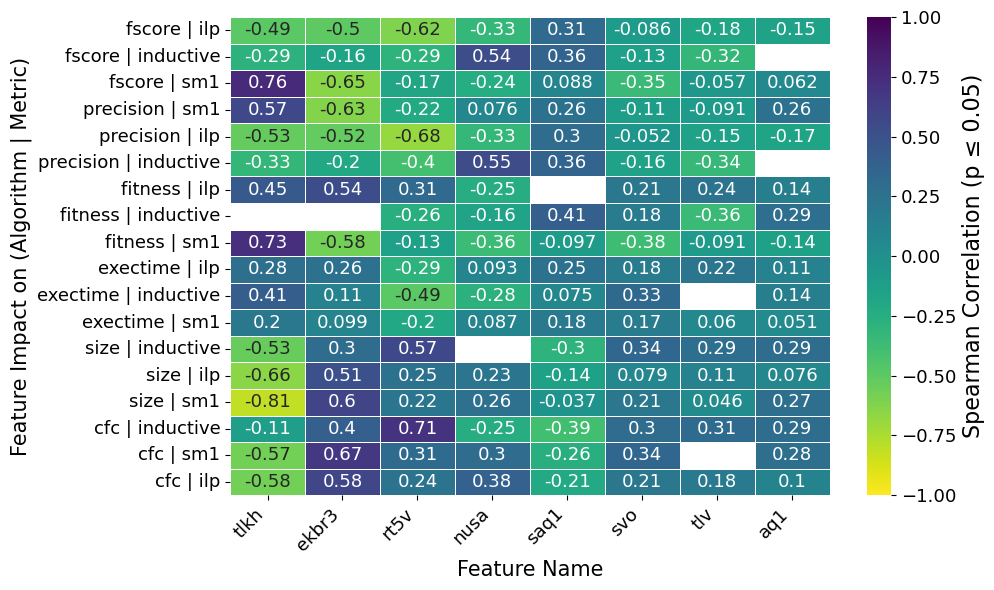

,tlkh,ekbr3,rt5v,nusa,saq1,svo,tlv,aq1
fscore | ilp,-0.487370,-0.501265,-0.616689,-0.329041,0.314246,-0.086305,-0.183095,-0.148516
fscore | inductive,-0.287599,-0.164567,-0.291581,0.538673,0.362285,-0.130743,-0.323126,-0.029266
fscore | sm1,0.761986,-0.648001,-0.173208,-0.237982,0.088372,-0.353652,-0.057362,0.061532
precision | sm1,0.566464,-0.627684,-0.218669,0.076205,0.257159,-0.105043,-0.091130,0.255152
precision | ilp,-0.525117,-0.516355,-0.683367,-0.328367,0.299067,-0.051729,-0.151826,-0.168373
precision | inductive,-0.327087,-0.202850,-0.399311,0.545373,0.360950,-0.155350,-0.340097,-0.007252
fitness | ilp,0.447979,0.538450,0.314133,-0.245954,-0.008636,0.208042,0.238278,0.143167
fitness | inductive,0.003380,-0.011396,-0.262965,-0.160001,0.405463,0.179347,-0.356048,0.287934
fitness | sm1,0.733040,-0.575518,-0.125869,-0.362793,-0.096728,-0.375552,-0.090812,-0.144503
exectime | ilp,0.275816,0.257208,-0.292393,0.093461,0.247368,0.175845,0.223896,0.111114


In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
FONTSIZE=15

data = shapley.copy()

# Create (metric | algorithm) labels
data['alg_metric'] = data['metric'] + " | " + data['algorithm']

# Get sorted axis labels
features = sorted(data['feature_name'].unique())
alg_metrics = sorted(data['alg_metric'].unique())

# Prepare correlation and p-value matrices
corr_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)
pval_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)

# Fill both matrices
for alg_metric in alg_metrics:
    for feature in features:
        subset = data[(data['alg_metric'] == alg_metric) & (data['feature_name'] == feature)]
        if len(subset) > 1:
            corr, p = spearmanr(subset['feature_value'], subset['shapley_value'])
            corr_matrix.loc[alg_metric, feature] = corr
            pval_matrix.loc[alg_metric, feature] = p
        else:
            corr_matrix.loc[alg_metric, feature] = np.nan
            pval_matrix.loc[alg_metric, feature] = np.nan

# Sort columns by average absolute correlation
corr_matrix = corr_matrix[corr_matrix.abs().mean().sort_values(ascending=False).index]
pval_matrix = pval_matrix[corr_matrix.columns]

# --- NEW BLOCK: Sort rows by average correlation per metric group ---
# Extract metric name (before the " | ")
corr_matrix['metric_group'] = corr_matrix.index.str.split(' \| ').str[0]

# Compute mean correlation across all features per metric group
metric_order = (
    corr_matrix
    .drop(columns='metric_group')  # exclude helper col
    .groupby(corr_matrix['metric_group'])
    .mean()
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

# Set categorical for sorting
corr_matrix['metric_group'] = pd.Categorical(corr_matrix['metric_group'], categories=metric_order, ordered=True)

# Sort index based on the new metric order
corr_matrix = corr_matrix.sort_values('metric_group', ascending= False).drop(columns='metric_group')
pval_matrix = pval_matrix.loc[corr_matrix.index]

# --- Plot ---
# Create mask: True where p > 0.05 (insignificant values to be hidden)
mask = pval_matrix > 0.05

plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='viridis_r',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation (p ≤ 0.05)"},
    annot_kws={"size": int(FONTSIZE * 0.9)}
)

colorbar = heatmap.collections[0].colorbar
colorbar.set_label("Spearman Correlation (p ≤ 0.05)", fontsize=int(FONTSIZE * 1.1))
colorbar.ax.tick_params(labelsize=int(FONTSIZE * 0.9))
#plt.title("Feature Value ↔ Shapley Correlation per (Algorithm, Metric)", fontsize=14)
plt.ylabel("Feature Impact on (Algorithm | Metric)", fontsize=FONTSIZE)
plt.xlabel("Feature Name", fontsize=FONTSIZE)
plt.xticks(rotation=45, ha='right', fontsize=int(FONTSIZE * 0.9))
plt.yticks(rotation=0, fontsize=int(FONTSIZE * 0.9))
plt.tight_layout()
plt.savefig(f"../output/plots/corr_spearman.png", dpi=300, bbox_inches='tight')

plt.show()

corr_matrix

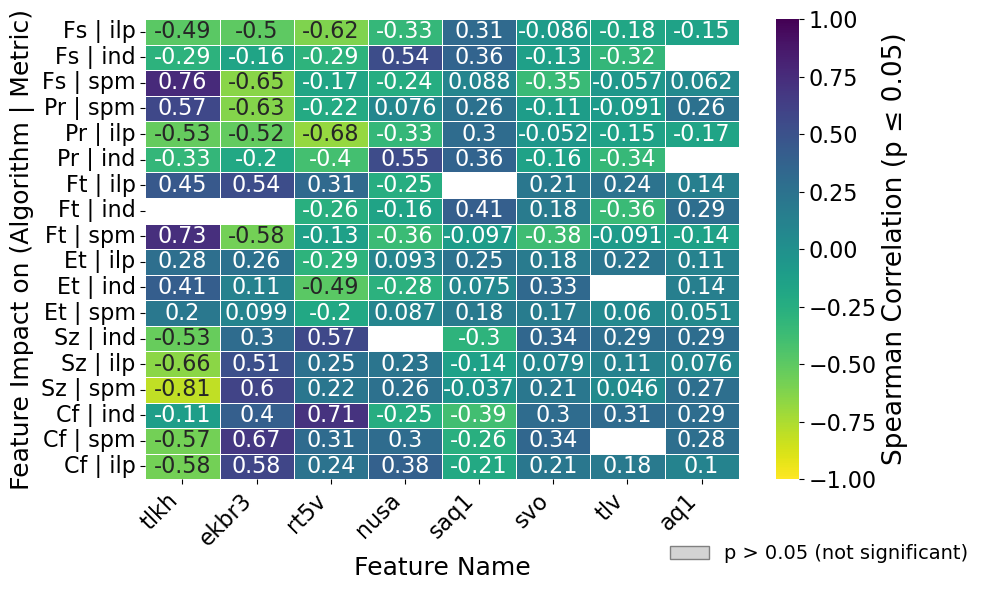

,tlkh,ekbr3,rt5v,nusa,saq1,svo,tlv,aq1
Fs | ilp,-0.487370,-0.501265,-0.616689,-0.329041,0.314246,-0.086305,-0.183095,-0.148516
Fs | ind,-0.287599,-0.164567,-0.291581,0.538673,0.362285,-0.130743,-0.323126,-0.029266
Fs | spm,0.761986,-0.648001,-0.173208,-0.237982,0.088372,-0.353652,-0.057362,0.061532
Pr | spm,0.566464,-0.627684,-0.218669,0.076205,0.257159,-0.105043,-0.091130,0.255152
Pr | ilp,-0.525117,-0.516355,-0.683367,-0.328367,0.299067,-0.051729,-0.151826,-0.168373
Pr | ind,-0.327087,-0.202850,-0.399311,0.545373,0.360950,-0.155350,-0.340097,-0.007252
Ft | ilp,0.447979,0.538450,0.314133,-0.245954,-0.008636,0.208042,0.238278,0.143167
Ft | ind,0.003380,-0.011396,-0.262965,-0.160001,0.405463,0.179347,-0.356048,0.287934
Ft | spm,0.733040,-0.575518,-0.125869,-0.362793,-0.096728,-0.375552,-0.090812,-0.144503
Et | ilp,0.275816,0.257208,-0.292393,0.093461,0.247368,0.175845,0.223896,0.111114


In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.patches import Patch

FONTSIZE = 18

# Copy data
data = shapley.copy()

# Define metric abbreviations
metric_abbrev = {
    'fitness': 'Ft',
    'precision': 'Pr',
    'fscore': 'Fs',
    'cfc': 'Cf',
    'exectime': 'Et',
    'size': 'Sz'
}

algo_abbrev = {
    'ilp': 'ilp',
    'sm1': 'spm',
    'inductive': 'ind',
}

# Abbreviate metric names and create (metric | algorithm) labels
data['metric_abbrev'] = data['metric'].map(metric_abbrev)
data['algorithm'] = data['algorithm'].map(algo_abbrev)
data['alg_metric'] = data['metric_abbrev'] + " | " + data['algorithm']

# Drop rows with missing labels (due to unmatched metrics)
data = data.dropna(subset=['alg_metric'])

# Get sorted axis labels
features = sorted(data['feature_name'].unique())
alg_metrics = sorted(data['alg_metric'].unique())

# Prepare correlation and p-value matrices
corr_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)
pval_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)

# Fill both matrices
for alg_metric in alg_metrics:
    for feature in features:
        subset = data[(data['alg_metric'] == alg_metric) & (data['feature_name'] == feature)]
        if len(subset) > 1:
            corr, p = spearmanr(subset['feature_value'], subset['shapley_value'])
            corr_matrix.loc[alg_metric, feature] = corr
            pval_matrix.loc[alg_metric, feature] = p
        else:
            corr_matrix.loc[alg_metric, feature] = np.nan
            pval_matrix.loc[alg_metric, feature] = np.nan

# Sort columns by average absolute correlation
corr_matrix = corr_matrix[corr_matrix.abs().mean().sort_values(ascending=False).index]
pval_matrix = pval_matrix[corr_matrix.columns]

# --- NEW BLOCK: Sort rows by average correlation per metric group ---
corr_matrix['metric_group'] = corr_matrix.index.str.split(' \| ').str[0]

# Compute mean correlation across all features per metric group
metric_order = (
    corr_matrix
    .drop(columns='metric_group')
    .groupby(corr_matrix['metric_group'])
    .mean()
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

# Set metric_group as a categorical variable for sorting
corr_matrix['metric_group'] = pd.Categorical(corr_matrix['metric_group'], categories=metric_order, ordered=True)

# Sort index by the new metric order
corr_matrix = corr_matrix.sort_values('metric_group', ascending=False).drop(columns='metric_group')
pval_matrix = pval_matrix.loc[corr_matrix.index]

# --- Plot ---
# Create mask: True where p > 0.05 (insignificant values to be hidden)
mask = pval_matrix > 0.05

plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='viridis_r',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Correlation (p ≤ 0.05)"},
    annot_kws={"size": int(FONTSIZE * 0.9)}
)

colorbar = heatmap.collections[0].colorbar
colorbar.set_label("Spearman Correlation (p ≤ 0.05)", fontsize=int(FONTSIZE * 1.1))
colorbar.ax.tick_params(labelsize=int(FONTSIZE * 0.9))

# Add custom legend for masked cells (grey color)
legend_elements = [Patch(facecolor='lightgrey', edgecolor='grey', label='p > 0.05 (not significant)')]
plt.legend(
    handles=legend_elements,
    loc='lower right',
    bbox_to_anchor=(1.4, -0.2),
    fontsize=int(FONTSIZE * 0.8),
    frameon=False,
    borderaxespad=0,
)

plt.ylabel("Feature Impact on (Algorithm | Metric)", fontsize=FONTSIZE)
plt.xlabel("Feature Name", fontsize=FONTSIZE)
plt.xticks(rotation=45, ha='right', fontsize=int(FONTSIZE * 0.9))
plt.yticks(rotation=0, fontsize=int(FONTSIZE * 0.9))
plt.tight_layout()
plt.savefig(f"../output/plots/corr_spearman.png", dpi=300, bbox_inches='tight')

plt.show()

corr_matrix

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2378809048.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('metric', group_keys=False).apply(normalize_shapley).reset_index(drop=True)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2378809048.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name', group_keys=False).apply(norm

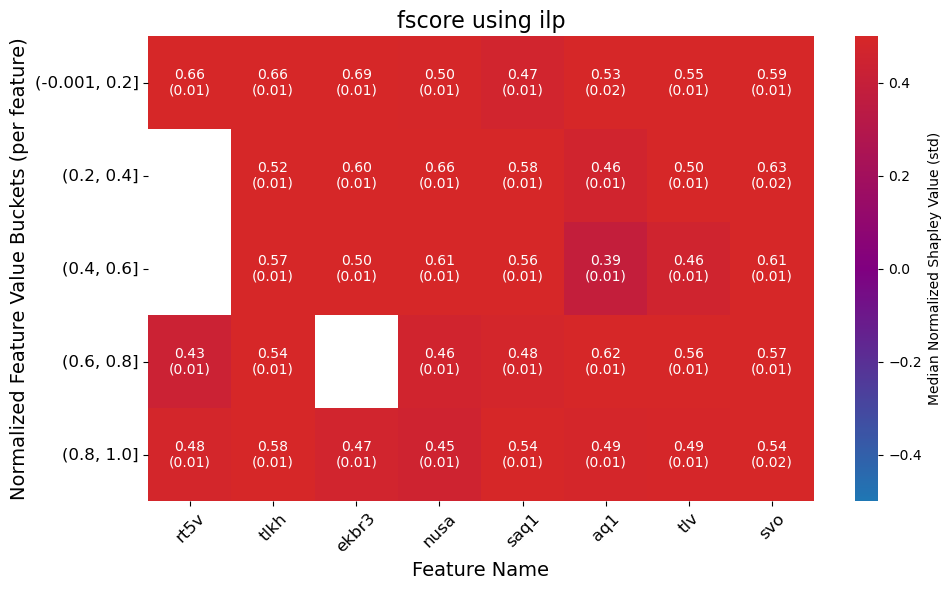

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import LinearSegmentedColormap

# Define custom colormap
shap_blue = "#1F77B4"
shap_red = "#D62728"
colors = [shap_blue, "purple", shap_red]
custom_cmap = LinearSegmentedColormap.from_list("BluePurpleRed", colors, N=256)

# Normalization functions
def normalize_group(group):
    scaler = MinMaxScaler()
    group['feature_value_normalized'] = scaler.fit_transform(group[['feature_value']])
    return group

def normalize_shapley(group):
    scaler = MinMaxScaler()
    group['shapley_normalized'] = scaler.fit_transform(group[['shapley_value']])
    return group

# Main plotting function
def plot_shapley_heatmap(shapley, algorithm, metric, custom_cmap=custom_cmap, bins=5,
                         order=['rt5v', 'tlkh', 'ekbr3', 'nusa', 'saq1', 'aq1', 'tlv', 'svo']):
    df = shapley[shapley['algorithm'] == algorithm].copy()

    # Normalize shapley and feature values
    df = df.groupby('metric', group_keys=False).apply(normalize_shapley).reset_index(drop=True)
    df = df.groupby('feature_name', group_keys=False).apply(normalize_group).reset_index(drop=True)
    df = df[df['metric'] == metric]

    # Bin feature values
    df['feature_value_bucket'] = pd.cut(df['feature_value_normalized'], bins=bins)

    # Set categorical order for consistent axis
    df['feature_name'] = pd.Categorical(df['feature_name'], categories=order, ordered=True)
    df['feature_value_bucket'] = pd.Categorical(df['feature_value_bucket'], ordered=True)

    # Aggregate
    agg = df.groupby(['feature_value_bucket', 'feature_name'])['shapley_normalized']
    agg_median = agg.median()
    agg_var = agg.var()
    agg_combined = pd.concat([agg_median, agg_var], axis=1).reset_index()
    agg_combined.columns = ['feature_value_bucket', 'feature_name', 'median', 'variance']

    # Pivot: feature_value_bucket on rows, feature_name on columns
    heatmap_data = agg_combined.pivot(index='feature_value_bucket', columns='feature_name', values='median')
    var_data = agg_combined.pivot(index='feature_value_bucket', columns='feature_name', values='variance')

    # Annotate matrix
    annot = pd.DataFrame('', index=heatmap_data.index, columns=heatmap_data.columns)
    for i in heatmap_data.index:
        for j in heatmap_data.columns:
            val = heatmap_data.loc[i, j]
            var = var_data.loc[i, j]
            if pd.isna(val):
                annot.loc[i, j] = ''
            else:
                annot.loc[i, j] = f"{val:.2f}\n({var:.2f})"

    # Plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        annot=annot,
        fmt='',
        cmap=custom_cmap,
        center=0,
        vmin=-0.5,
        vmax=0.5,
        cbar_kws={'label': 'Median Normalized Shapley Value (std)'}
    )

    plt.title(f"{metric} using {algorithm}", fontsize=16)
    plt.xlabel('Feature Name', fontsize=14)
    plt.ylabel('Normalized Feature Value Buckets (per feature)', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../output/plots/heat_oshap_{metric}_{algorithm}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Example usage:
plot_shapley_heatmap(shapley, algorithm, 'fscore', custom_cmap=custom_cmap)

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/4124247527.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/4124247527.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

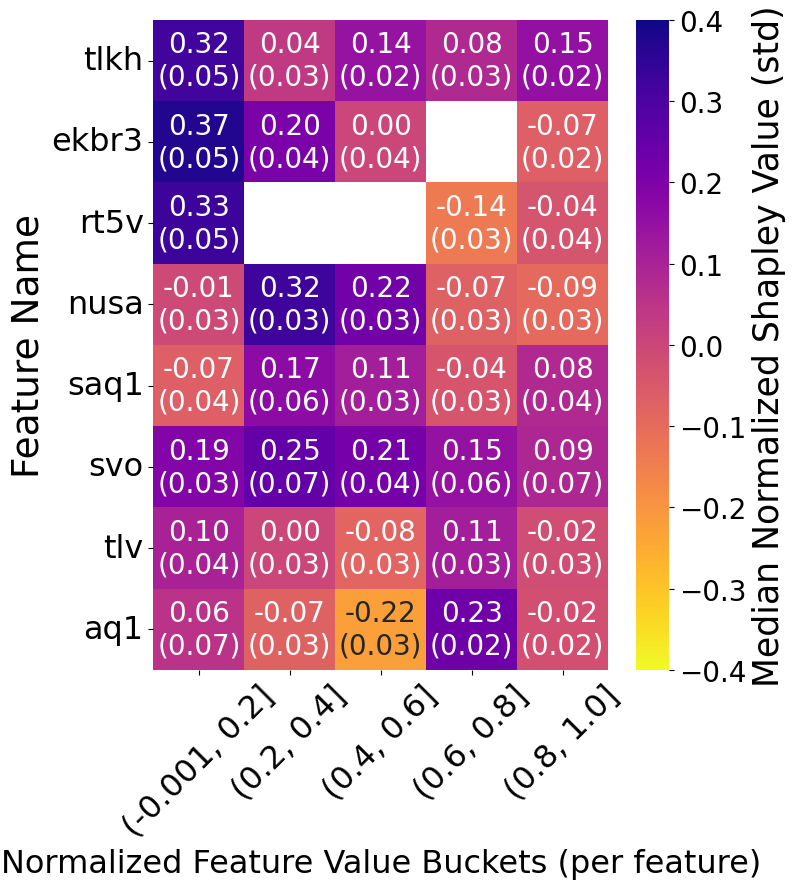

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

shap_blue = "#1F77B4"
shap_red = "#D62728"
colors = [shap_blue, "purple", shap_red]
custom_cmap = LinearSegmentedColormap.from_list("BluePurpleRed", colors, N=256)

def normalize_group(group):
    scaler = MinMaxScaler()
    group['feature_value_normalized'] = scaler.fit_transform(group[['feature_value']])
    return group

def plot_shapley_heatmap(shapley, algorithm, metric, custom_cmap='viridis_r', bins=5,
                         order=['tlkh', 'ekbr3','rt5v', 'nusa', 'saq1','svo', 'tlv','aq1'],
                         FONTSIZE=16):
    df = shapley[shapley['algorithm'] == algorithm].copy()

    # Normalize Shapley values
    df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
    df = df.groupby('feature_name').apply(normalize_group).reset_index(drop=True)
    df = df[df['metric'] == metric]
    df['feature_value_bucket'] = pd.cut(df['feature_value_normalized'], bins=bins)

    # Aggregation
    agg = df.groupby(['feature_name', 'feature_value_bucket'])['shapley_normalized']
    agg_median = agg.median()
    agg_var = agg.var()
    agg_combined = pd.concat([agg_median, agg_var], axis=1).reset_index()
    agg_combined.columns = ['feature_name', 'feature_value_bucket', 'median', 'variance']
    agg_combined['feature_name'] = pd.Categorical(agg_combined['feature_name'],
                                                  categories=order, ordered=True)
    agg_combined = agg_combined.sort_values('feature_name').reset_index(drop=True)

    # Pivot for heatmap
    heatmap_data = agg_combined.pivot(index='feature_name', columns='feature_value_bucket', values='median')
    var_data = agg_combined.pivot(index='feature_name', columns='feature_value_bucket', values='variance')

    # Annotate with variance
    annot = heatmap_data.copy().astype(str)
    for i in heatmap_data.index:
        for j in heatmap_data.columns:
            val = heatmap_data.loc[i, j]
            var = var_data.loc[i, j]
            if pd.isna(val):
                annot.loc[i, j] = ''
            else:
                annot.loc[i, j] = f"{val:.2f}\n({var:.2f})"

    plt.figure(figsize=(8, 9))
    heatmap = sns.heatmap(
        heatmap_data,
        annot=annot,
        fmt='',
        cmap=custom_cmap,
        center=0,
        vmin=-0.4,
        vmax=0.4,
        cbar_kws={'label': 'Median Normalized Shapley Value (std)'},
        annot_kws={"size": int(FONTSIZE * 0.9)}
    )

    colorbar = heatmap.collections[0].colorbar
    colorbar.set_label('Median Normalized Shapley Value (std)', fontsize=int(FONTSIZE * 1.1))
    colorbar.ax.tick_params(labelsize=int(FONTSIZE * 0.9))

    #plt.title(f"{metric} using {algorithm}", fontsize=int(FONTSIZE * 1.5))
    plt.xlabel('Normalized Feature Value Buckets (per feature)', fontsize=int(FONTSIZE * 1.0))
    plt.ylabel('Feature Name', fontsize=int(FONTSIZE * 1.2))
    plt.xticks(rotation=45, fontsize=int(FONTSIZE * 1))
    plt.yticks(rotation=0, fontsize=int(FONTSIZE * 1))

    plt.tight_layout()
    plt.savefig(f"../output/plots/heat_oshap_{metric}_{algorithm}.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_shapley_heatmap(shapley, algorithm, 'fscore', custom_cmap='plasma_r', FONTSIZE=23)

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                      -0.204525         NaN         NaN         NaN   
ekbr3                      0.334160    0.223048    0.124619    0.078964   
rt5v                       0.320775    0.088760         NaN         NaN   
nusa                       0.143118    0.241025    0.126277    0.166924   
saq1                       0.204564    0.218859    0.016424    0.125626   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                    0.126267  
ekbr3                   0.157605  
rt5v                    0.277571  
nusa                    0.014483  
saq1                    0.205663  


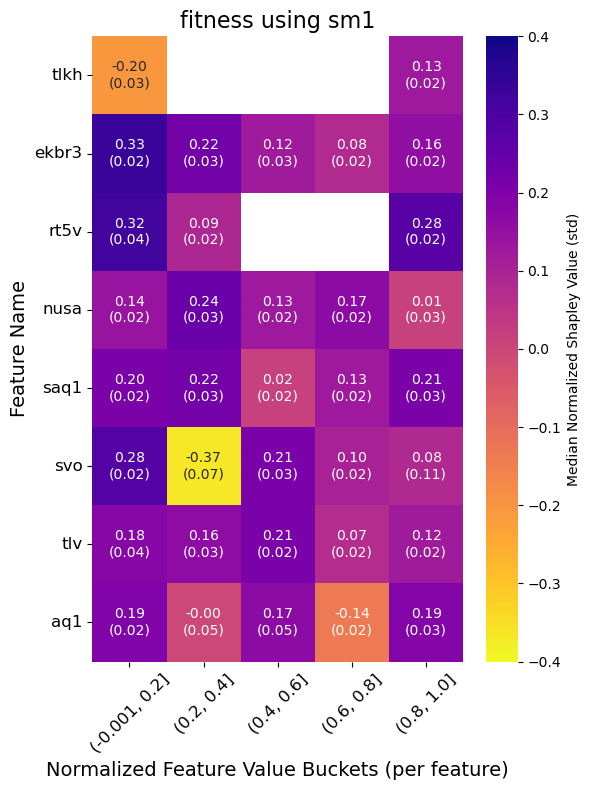

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                       0.071089         NaN         NaN         NaN   
ekbr3                      0.340692    0.232999    0.076171    0.100905   
rt5v                       0.236420   -0.016142         NaN         NaN   
nusa                       0.143609    0.235686    0.235830    0.193404   
saq1                      -0.023949    0.158213   -0.118861    0.148966   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                    0.273223  
ekbr3                   0.028033  
rt5v                    0.135410  
nusa                    0.153579  
saq1                    0.078565  


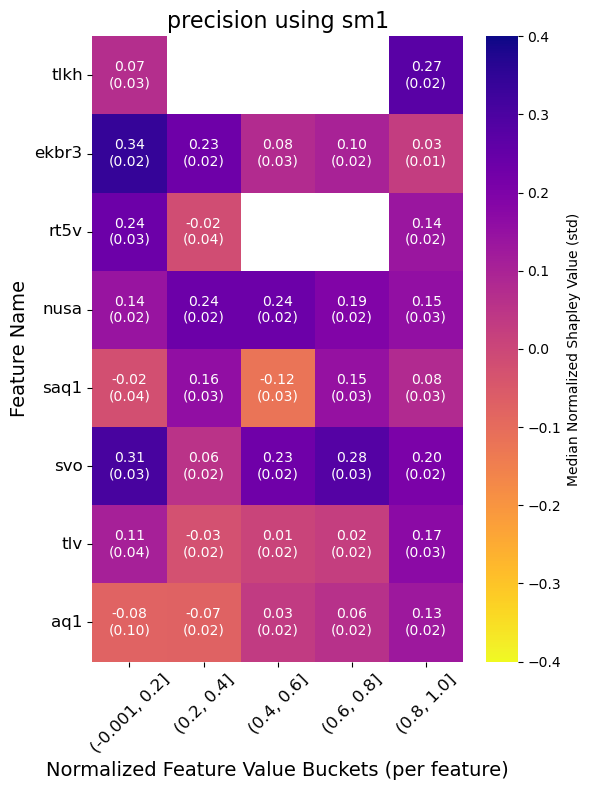

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                      -0.192695         NaN         NaN         NaN   
ekbr3                      0.368599    0.232174    0.093149    0.083667   
rt5v                       0.283443    0.028903         NaN         NaN   
nusa                       0.124729    0.234451    0.145672    0.175618   
saq1                       0.091809    0.188121   -0.073160    0.116485   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                    0.187326  
ekbr3                   0.063947  
rt5v                    0.210870  
nusa                    0.036490  
saq1                    0.136765  


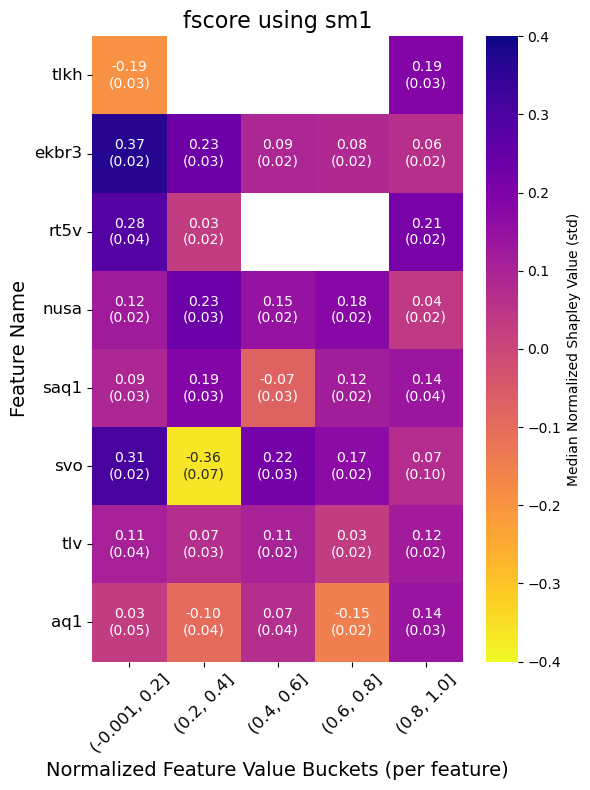

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                       0.119266         NaN         NaN         NaN   
ekbr3                     -0.201835   -0.119266    0.211009    0.513761   
rt5v                      -0.128440    0.348624         NaN         NaN   
nusa                       0.055046   -0.091743   -0.055046    0.211009   
saq1                       0.091743   -0.045872    0.100917    0.091743   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                   -0.064220  
ekbr3                  -0.073394  
rt5v                   -0.018349  
nusa                    0.220183  
saq1                   -0.009174  


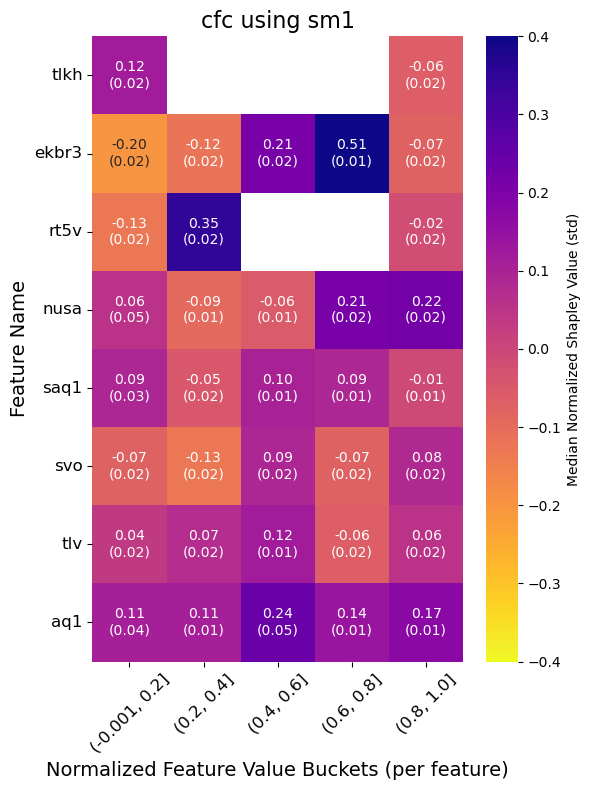

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                       0.354651         NaN         NaN         NaN   
ekbr3                     -0.220930   -0.171512    0.145349    0.453488   
rt5v                      -0.151163    0.372093         NaN         NaN   
nusa                       0.017442   -0.052326   -0.046512    0.104651   
saq1                       0.133721   -0.116279    0.279070    0.139535   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                   -0.127907  
ekbr3                   0.122093  
rt5v                   -0.040698  
nusa                    0.174419  
saq1                    0.058140  


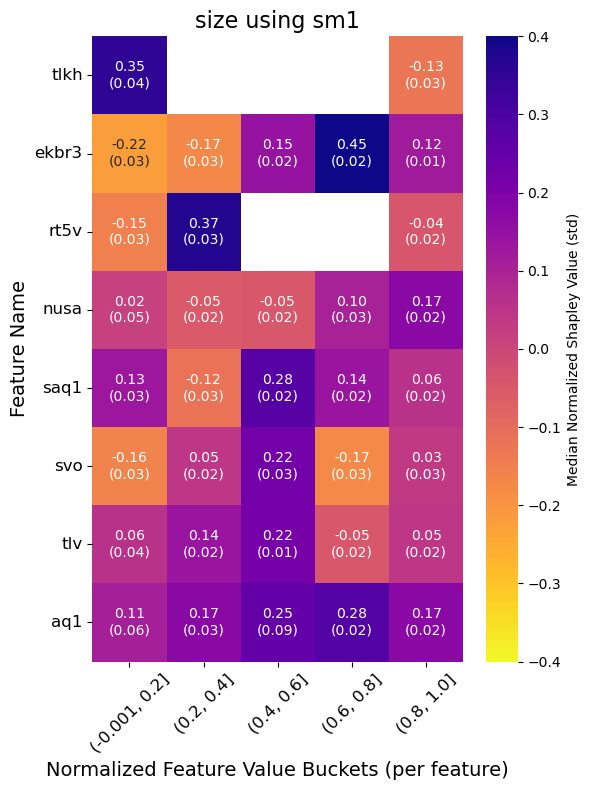

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_49579/2196522919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('feature_name').apply(normalize_group).reset_

feature_value_bucket  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  \
feature_name                                                              
tlkh                      -0.084077         NaN         NaN         NaN   
ekbr3                     -0.073810   -0.076705   -0.067461   -0.052067   
rt5v                      -0.062294    0.055972         NaN         NaN   
nusa                      -0.038519   -0.064034   -0.059027   -0.053050   
saq1                      -0.079867   -0.085233   -0.073770   -0.057087   

feature_value_bucket  (0.8, 1.0]  
feature_name                      
tlkh                   -0.061936  
ekbr3                   0.057805  
rt5v                   -0.088885  
nusa                   -0.007837  
saq1                   -0.055467  


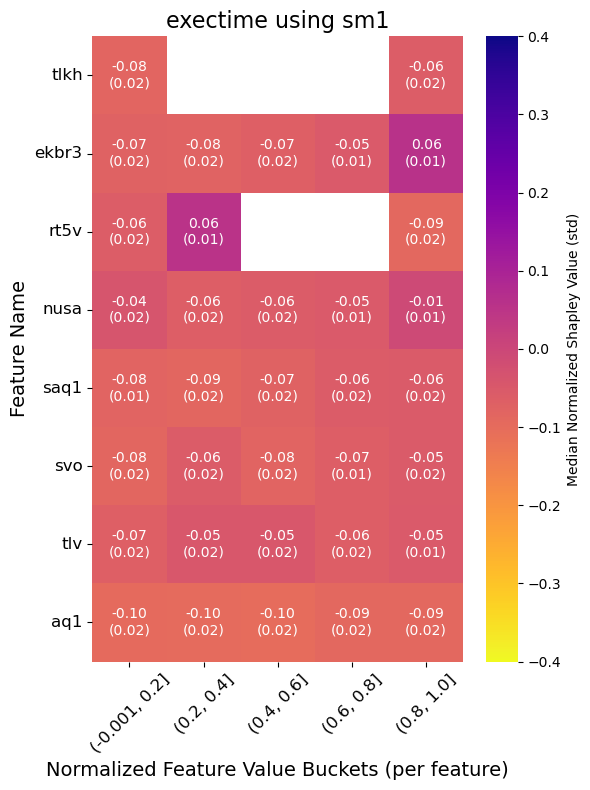

In [42]:
algorithm = 'sm1'
for metric in METRIC_ORDER:
    plot_shapley_heatmap(shapley, algorithm, metric, custom_cmap='plasma_r')

In [ ]:
df = shapley.copy()
df['shapley_normalized'] = df.groupby('metric', group_keys=False).apply(normalize_shapley)
df = df.groupby('feature_name').apply(normalize_group).reset_index(drop=True)

df.head()

In [ ]:
corr_matrix
sorted_columns_per_row = corr_matrix.apply(lambda row: row.sort_values(ascending=False).index.tolist(), axis=1)

# Display result
sorted_columns_df = pd.DataFrame(sorted_columns_per_row.tolist(), index=corr_matrix.index)
#plot_shapley_heatmap(shapley, algorithm, 'precision', order = sorted_columns_df.loc['precision'+' | '+algorithm ]) 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

data = shapley.copy()

# Create label for rows
data['alg_metric'] = data['metric'] + " | " + data['algorithm']

# Define row/column labels
features = sorted(data['feature_name'].unique())
alg_metrics = sorted(data['alg_metric'].unique())

# Prepare empty matrices
corr_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)
pval_matrix = pd.DataFrame(index=alg_metrics, columns=features, dtype=float)

# Fill matrices
for alg_metric in alg_metrics:
    for feature in features:
        subset = data[(data['alg_metric'] == alg_metric) & (data['feature_name'] == feature)]
        if len(subset) > 1:
            corr, p = spearmanr(subset['feature_value'], subset['shapley_value'])
            corr_matrix.loc[alg_metric, feature] = corr
            pval_matrix.loc[alg_metric, feature] = p

# Mask non-significant correlations
significant_corrs = corr_matrix.where(pval_matrix <= 0.05)

# Drop rows and columns where all values are NaN (optional)
significant_corrs = significant_corrs.dropna(how='all').dropna(axis=1, how='all')

# Display as a table
print("Significant correlations (p ≤ 0.05):")
print(significant_corrs)

# Save to CSV (optional)
# significant_corrs.to_csv("significant_spearman_correlations.csv")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Copy original data
data = shapley.copy()

# Z-score normalization per metric
data['norm_shapley'] = data.groupby('metric')['shapley_value'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

# Combine algorithm and metric into one label
data['alg_metric'] = data['metric'] + " | " + data['algorithm']
#print(data)

# Prepare the heatmap matrix
features = sorted(data['feature_name'].unique())
alg_metrics = sorted(data['alg_metric'].unique())

heatmap_data = pd.DataFrame(index=alg_metrics, columns=features)

# Compute mean normalized shapley values
for alg_metric in alg_metrics:
    for feature in features:
        subset = data[(data['alg_metric'] == alg_metric) & (data['feature_name'] == feature)]
        if len(subset) > 0:
            mean_norm = subset['norm_shapley'].mean()
            heatmap_data.loc[alg_metric, feature] = mean_norm
        else:
            heatmap_data.loc[alg_metric, feature] = np.nan

# Convert to float
heatmap_data = heatmap_data.astype(float)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap=custom_cmap, center=0, linewidths=0.5,
            cbar_kws={"label": "Mean Normalized Shapley Value (Z-score)"})
plt.title("Mean Z-Score Normalized Shapley per Feature per (Algorithm | Metric)", fontsize=14)
plt.ylabel("Feature Impact on (Algorithm | Metric)", fontsize=12)
plt.xlabel("Feature Name", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [72]:
INPUT_PATH = "../../shampu/output/8fts_3miners_ind_ilp_sm1_3456_shapley.csv"
data = pd.read_csv(INPUT_PATH)
#features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
shapley = data[~data['metric'].isin(['benchtime', 'pnsize'])]
#shapley = data.copy()
print(shapley['algorithm'].unique())
print(shapley.shape)
shapley.head()

['inductive' 'sm1' 'ilp']
(90072, 5)


,algorithm,metric,feature_name,feature_value,shapley_value
5004,inductive,cfc,aq1,6413,11.833333
5005,inductive,cfc,svo,758,-5.166667
5006,inductive,cfc,tlv,2776,4.333333
5007,inductive,cfc,aq1,6413,9.833333
5008,inductive,cfc,svo,758,-4.166667


/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/2197059060.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='algorithm', y='norm_shapley', palette='Set2')


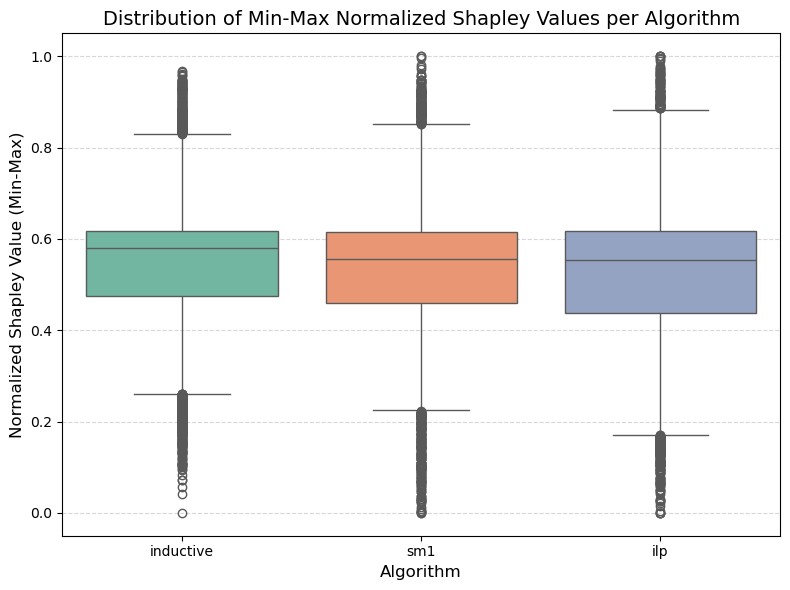

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

data = shapley.copy()

# Min-Max normalization per metric
data['norm_shapley'] = data.groupby('metric')['shapley_value'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='algorithm', y='norm_shapley', palette='Set2')

plt.title("Distribution of Min-Max Normalized Shapley Values per Algorithm", fontsize=14)
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Normalized Shapley Value (Min-Max)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


        algorithm metric feature_name  feature_value  shapley_value
5004    inductive    cfc          aq1           6413      11.833333
5005    inductive    cfc          svo            758      -5.166667
5006    inductive    cfc          tlv           2776       4.333333
5007    inductive    cfc          aq1           6413       9.833333
5008    inductive    cfc          svo            758      -4.166667
...           ...    ...          ...            ...            ...
120091        ilp   size          svo            758      15.333333
120092        ilp   size         saq1           2443      -1.166667
120093        ilp   size          aq1           6413      10.000000
120094        ilp   size          svo            758      11.500000
120095        ilp   size         saq1          27906      -0.500000

[90072 rows x 5 columns]


/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_88709/3194320835.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='algorithm', y='norm_shapley', palette='Set2', inner='box')


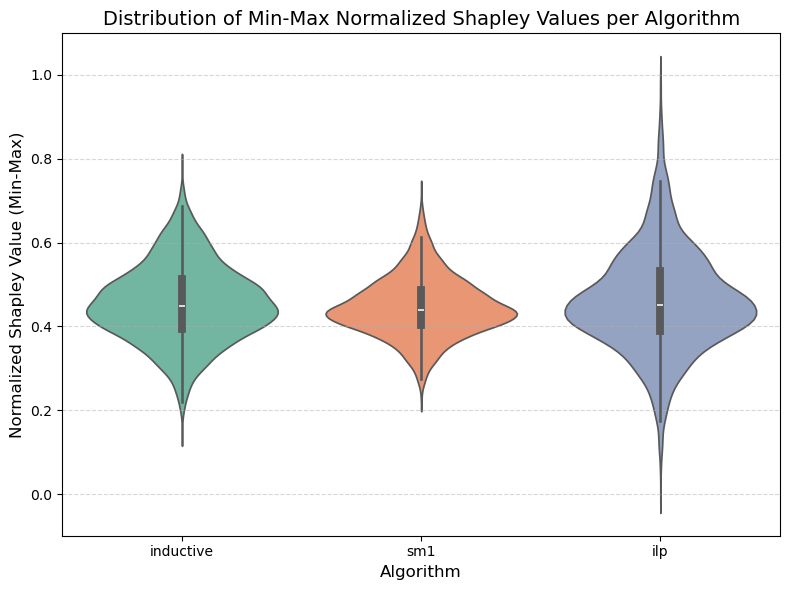

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

data = shapley.copy()
data = data[data['metric']=='size']
print(shapley)


# Min-Max normalization per metric
data['norm_shapley'] = data.groupby('metric')['shapley_value'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x='algorithm', y='norm_shapley', palette='Set2', inner='box')

plt.title("Distribution of Min-Max Normalized Shapley Values per Algorithm", fontsize=14)
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Normalized Shapley Value (Min-Max)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


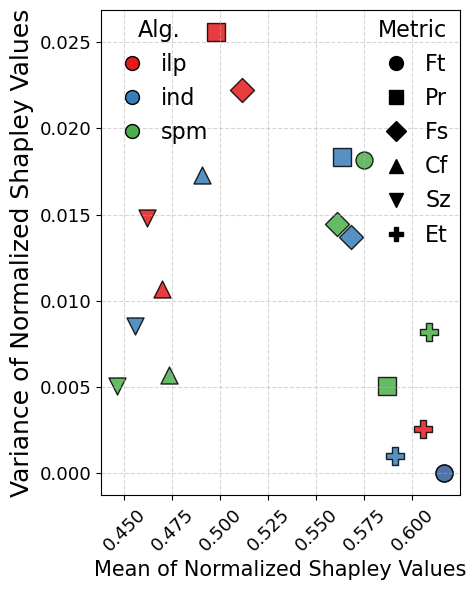

In [121]:
FONTSIZE = 18

plt.figure(figsize=(6, 6))

for _, row in summary.iterrows():
    metric = row['metric']
    if metric in desired_metric_order:
        plt.scatter(
            row['mean'],
            row['var'],
            s=150,
            color=algo_colors[row['algorithm']],
            edgecolor='black',
            marker=metric_markers[metric],
            alpha=0.85,
        )

algo_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=algo_abbrev.get(algo, algo),  # Use abbreviation if available
           markerfacecolor=algo_colors[algo], markersize=10, markeredgecolor='black')
    for algo in algorithms
]

metric_handles = [
    Line2D([0], [0], marker=metric_markers[metric], color='k',
           label=metric_abbrev.get(metric, metric),  # Use abbreviation if available
           linestyle='None', markersize=10)
    for metric in desired_metric_order
]

leg1 = plt.legend(handles=algo_handles, title='Alg.',
                  loc='upper left',
                  fontsize=int(FONTSIZE * 0.9),
                  title_fontsize=int(FONTSIZE * 0.9),
                  handletextpad=0.3,
                  columnspacing=0.4,
                  borderpad=-0.1,
                  frameon=False)

leg2 = plt.legend(handles=metric_handles, title='Metric',
                  loc='upper right',
                  fontsize=int(FONTSIZE * 0.9),
                  title_fontsize=int(FONTSIZE * 0.9),
                  handletextpad=0.3,
                  columnspacing=0.4,
                  borderpad=-0.1,
                  frameon=False)

plt.gca().add_artist(leg1)

plt.xlabel("Mean of Normalized Shapley Values", fontsize=int(FONTSIZE * 0.85))
plt.ylabel("Variance of Normalized Shapley Values", fontsize=int(FONTSIZE * 1.0))

# plt.title("Mean vs. Variance of Normalized Shapley Values\nper Algorithm and Metric",
#           fontsize=int(FONTSIZE * 1.2), weight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, fontsize=int(FONTSIZE * 0.75))
plt.yticks(fontsize=int(FONTSIZE * 0.75))
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.savefig(f"../output/plots/mean_var_shap_3miners.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

data = shapley.copy()

# Min-Max normalization per metric
data['norm_shapley'] = data.groupby('metric')['shapley_value'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# Compute mean and variance per algorithm and metric
summary = data.groupby(['metric', 'algorithm'])['norm_shapley'].agg(['mean', 'var']).reset_index()

algorithms = summary['algorithm'].unique()
palette = sns.color_palette("Set2", n_colors=len(algorithms))
algo_colors = dict(zip(algorithms, palette))

desired_metric_order = ['fitness', 'precision', 'fscore', 'cfc', 'size', 'exectime']
markers = ['o', 's', 'D', '^', 'v', 'P']
metric_markers = dict(zip(desired_metric_order, markers))

plt.figure(figsize=(8, 6))

for _, row in summary.iterrows():
    metric = row['metric']
    if metric in desired_metric_order:
        plt.scatter(
            row['mean'],
            row['var'],
            s=100,  # smaller marker for tighter look
            color=algo_colors[row['algorithm']],
            edgecolor='black',
            marker=metric_markers[metric],
            alpha=0.85,
            linewidth=0.7,
        )

# Legend handles for algorithms (colors)
algo_handles = [
    Line2D([0], [0], marker='o', color='w', label=algo,
           markerfacecolor=algo_colors[algo], markersize=7, markeredgecolor='black', linewidth=0.7)
    for algo in algorithms
]

# Legend handles for metrics (marker shapes)
metric_handles = [
    Line2D([0], [0], marker=metric_markers[metric], color='k', label=metric,
           linestyle='None', markersize=7, markeredgewidth=0.7)
    for metric in desired_metric_order
]

# Place legends inside plot at top right and top left to reduce whitespace
leg1 = plt.legend(handles=algo_handles, title='Algorithm',
                  loc='upper left', fontsize=9, title_fontsize=10,
                  handletextpad=0.3, columnspacing=0.4, borderpad=0.3, frameon=False)

leg2 = plt.legend(handles=metric_handles, title='Metric',
                  loc='upper right', fontsize=9, title_fontsize=10,
                  handletextpad=0.3, columnspacing=0.4, borderpad=0.3, frameon=False)

plt.gca().add_artist(leg1)  # Add first legend back

plt.xlabel("Mean of Normalized Shapley Values", fontsize=11)
plt.ylabel("Variance of Normalized Shapley Values", fontsize=11)
plt.title("Mean vs. Variance of Normalized Shapley Values\nper Algorithm and Metric", fontsize=13, weight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()